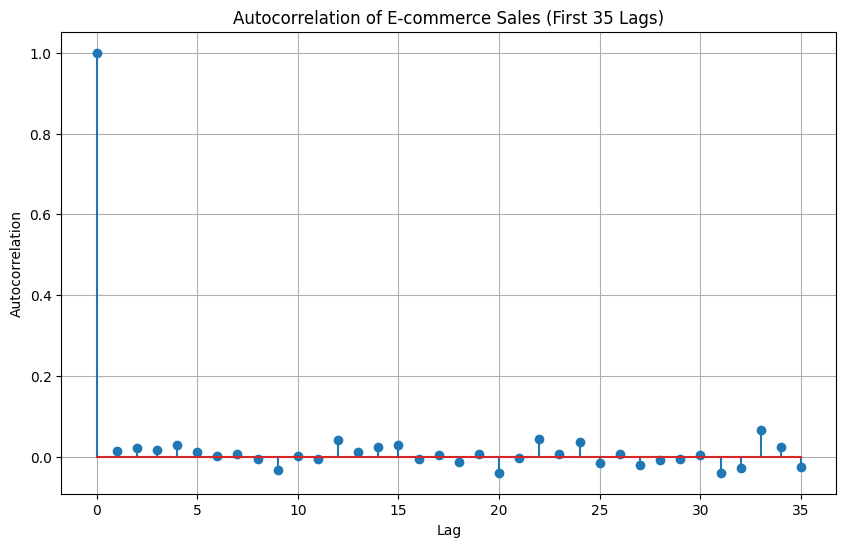

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load ecommerce dataset
data = pd.read_csv("/kaggle/input/datasets/santhoshd17/exercise-3/ecommerce_sales_data (2).csv",
                   parse_dates=['Order Date'],
                   index_col='Order Date')

# Aggregate sales per day (important for ecommerce)
data = data.groupby('Order Date')['Sales'].sum().to_frame()

# Extract sales values
sales_values = data['Sales'].dropna().values
N = len(sales_values)

# Define first 35 lags
lags = range(36)
autocorr_values = []

# Mean and variance
mean_data = np.mean(sales_values)
variance_data = np.var(sales_values)

# Manual ACF calculation
for lag in lags:
    if lag == 0:
        autocorr_values.append(1)
    else:
        auto_cov = np.sum((sales_values[:-lag] - mean_data) *
                          (sales_values[lag:] - mean_data)) / N
        autocorr_values.append(auto_cov / variance_data)

# Plot ACF
plt.figure(figsize=(10, 6))
plt.stem(lags, autocorr_values)
plt.title('Autocorrelation of E-commerce Sales (First 35 Lags)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()